# 05 · Análisis exploratorio con visualización (Pandas, Matplotlib, Seaborn)

**Objetivo:** entender qué variables se relacionan con el éxito del aterrizaje y preparar las variables
para el modelo (*feature engineering* con One-Hot Encoding).

En todas las gráficas: **verde = aterrizó (1)** y **rojo = no aterrizó (0)**.

In [1]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
IMAGES_DIR = Path("../images")
for folder in (DATA_DIR, RESULTS_DIR, IMAGES_DIR):
    folder.mkdir(exist_ok=True)

# Repositorio público de datos del curso IBM Applied Data Science Capstone
IBM = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork"


def load_csv(name: str, url: str) -> pd.DataFrame:
    """Lee data/<name> si ya existe; si no, lo descarga desde `url` y lo guarda como caché local."""
    local = DATA_DIR / name
    if local.exists():
        print(f"Leyendo {local}")
        return pd.read_csv(local)
    print(f"Descargando {url}")
    df = pd.read_csv(url)
    df.to_csv(local, index=False)
    return df

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
# Colores semánticos usados en todo el proyecto: rojo = no aterrizó, verde = aterrizó
CLASS_PALETTE = {0: "#D64545", 1: "#1FA67A"}
CLASS_LABELS = {0: "No aterrizó (0)", 1: "Aterrizó (1)"}


def save(fig, name: str) -> None:
    fig.savefig(IMAGES_DIR / name, dpi=150, bbox_inches="tight")
    print("guardada", IMAGES_DIR / name)

In [3]:
df = load_csv("dataset_part_2.csv", f"{IBM}/datasets/dataset_part_2.csv")
df["Year"] = pd.to_datetime(df["Date"]).dt.year
print(df.shape)
df.head()

Leyendo ../data/dataset_part_2.csv
(90, 19)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


## 1. Número de vuelo vs. masa de carga útil

guardada ../images/eda_flight_vs_payload.png


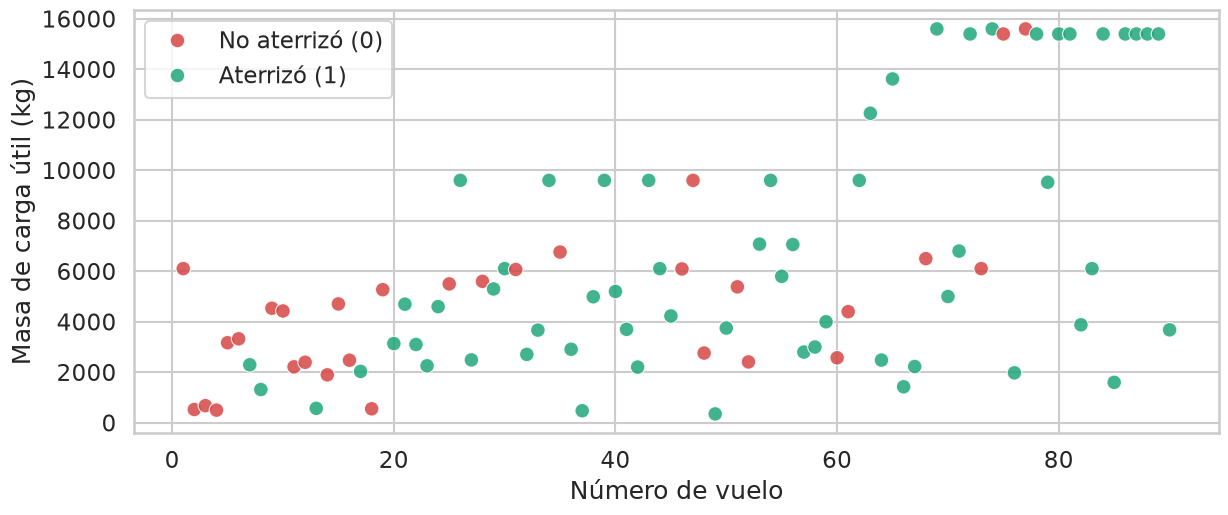

In [4]:
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.scatterplot(data=df, x="FlightNumber", y="PayloadMass", hue="Class", palette=CLASS_PALETTE,
                s=110, alpha=0.85, ax=ax)
ax.set(xlabel="Número de vuelo", ylabel="Masa de carga útil (kg)")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=[CLASS_LABELS[0], CLASS_LABELS[1]], title=None)
save(fig, "eda_flight_vs_payload.png")
plt.show()

**Lectura:** a medida que aumenta el número de vuelo, los aterrizajes exitosos son más frecuentes, incluso
con cargas pesadas. La experiencia acumulada importa.

## 2. Número de vuelo vs. sitio de lanzamiento

guardada ../images/eda_flight_vs_site.png


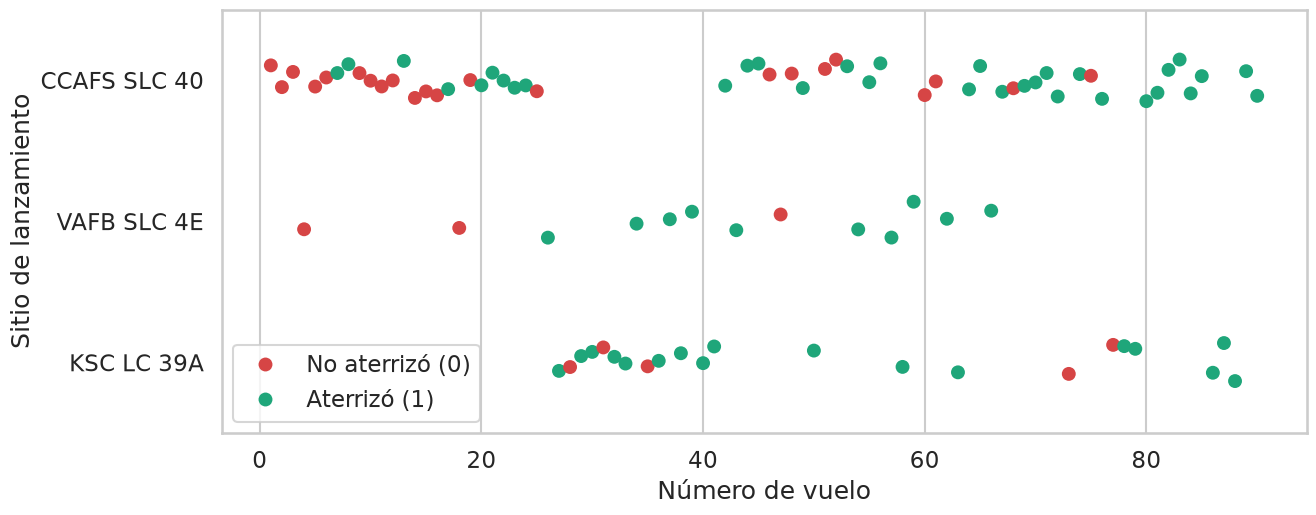

In [5]:
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.stripplot(data=df, x="FlightNumber", y="LaunchSite", hue="Class", palette=CLASS_PALETTE,
              size=10, jitter=0.15, ax=ax)
ax.set(xlabel="Número de vuelo", ylabel="Sitio de lanzamiento")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=[CLASS_LABELS[0], CLASS_LABELS[1]], title=None)
save(fig, "eda_flight_vs_site.png")
plt.show()

**Lectura:** los primeros vuelos (casi todos fallidos) salieron de CCAFS SLC-40. Los vuelos posteriores, en
todos los sitios, tienen una proporción de éxito mucho mayor.

## 3. Masa de carga útil vs. sitio de lanzamiento

guardada ../images/eda_payload_vs_site.png


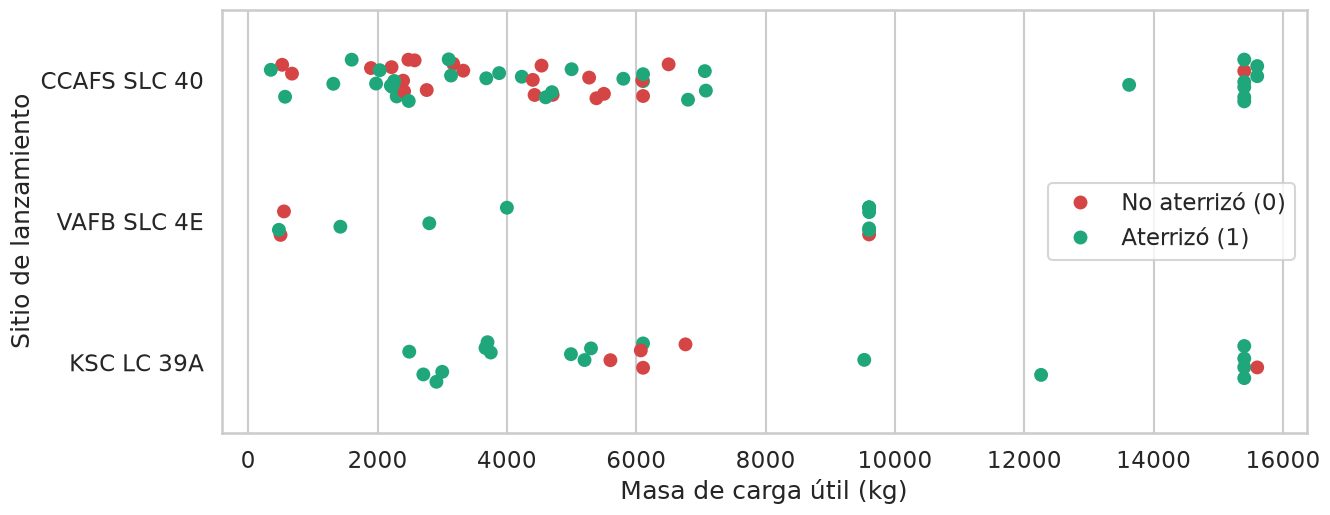

In [6]:
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.stripplot(data=df, x="PayloadMass", y="LaunchSite", hue="Class", palette=CLASS_PALETTE,
              size=10, jitter=0.15, ax=ax)
ax.set(xlabel="Masa de carga útil (kg)", ylabel="Sitio de lanzamiento")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=[CLASS_LABELS[0], CLASS_LABELS[1]], title=None)
save(fig, "eda_payload_vs_site.png")
plt.show()

**Lectura:** en VAFB SLC-4E no hay lanzamientos con cargas muy pesadas (> 10.000 kg). Las cargas más
pesadas salen de Florida y muestran una alta proporción de aterrizajes exitosos.

## 4. Tasa de éxito por tipo de órbita

guardada ../images/eda_success_by_orbit.png


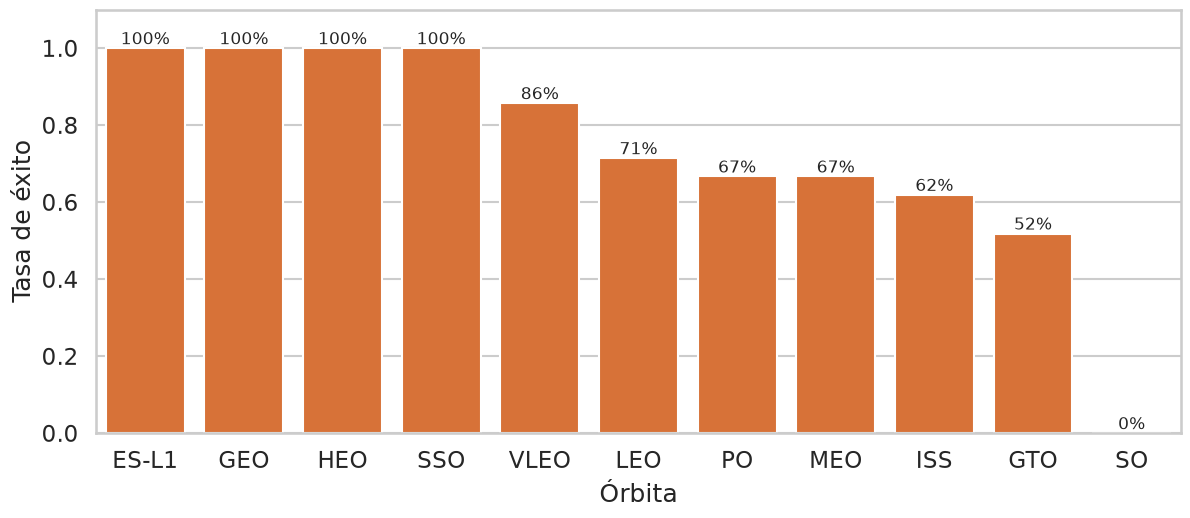

Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
PO       0.666667
MEO      0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000
Name: Class, dtype: float64

In [7]:
orbit_rate = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.barplot(x=orbit_rate.index, y=orbit_rate.values, color="#F26B1D", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{v:.0%}" for v in orbit_rate.values], fontsize=12)
ax.set(xlabel="Órbita", ylabel="Tasa de éxito", ylim=(0, 1.1))
save(fig, "eda_success_by_orbit.png")
plt.show()
orbit_rate

**Lectura:** ES-L1, GEO, HEO y SSO muestran 100 % de éxito, pero con muy pocos lanzamientos cada una
(hay que leerlas con cautela). GTO, la órbita comercial más frecuente, tiene una tasa cercana al 50 %.

## 5. Número de vuelo vs. tipo de órbita

guardada ../images/eda_flight_vs_orbit.png


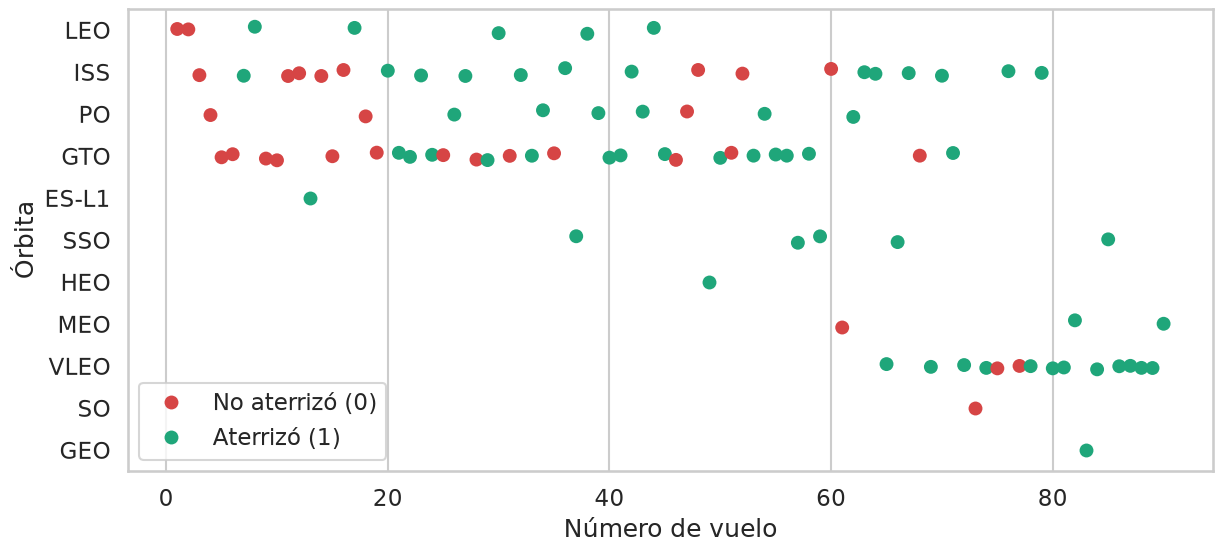

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df, x="FlightNumber", y="Orbit", hue="Class", palette=CLASS_PALETTE,
              size=10, jitter=0.1, ax=ax)
ax.set(xlabel="Número de vuelo", ylabel="Órbita")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=[CLASS_LABELS[0], CLASS_LABELS[1]], title=None)
save(fig, "eda_flight_vs_orbit.png")
plt.show()

**Lectura:** en LEO el éxito parece aumentar con el número de vuelo; en GTO no se aprecia una relación clara
entre número de vuelo y éxito.

## 6. Masa de carga útil vs. tipo de órbita

guardada ../images/eda_payload_vs_orbit.png


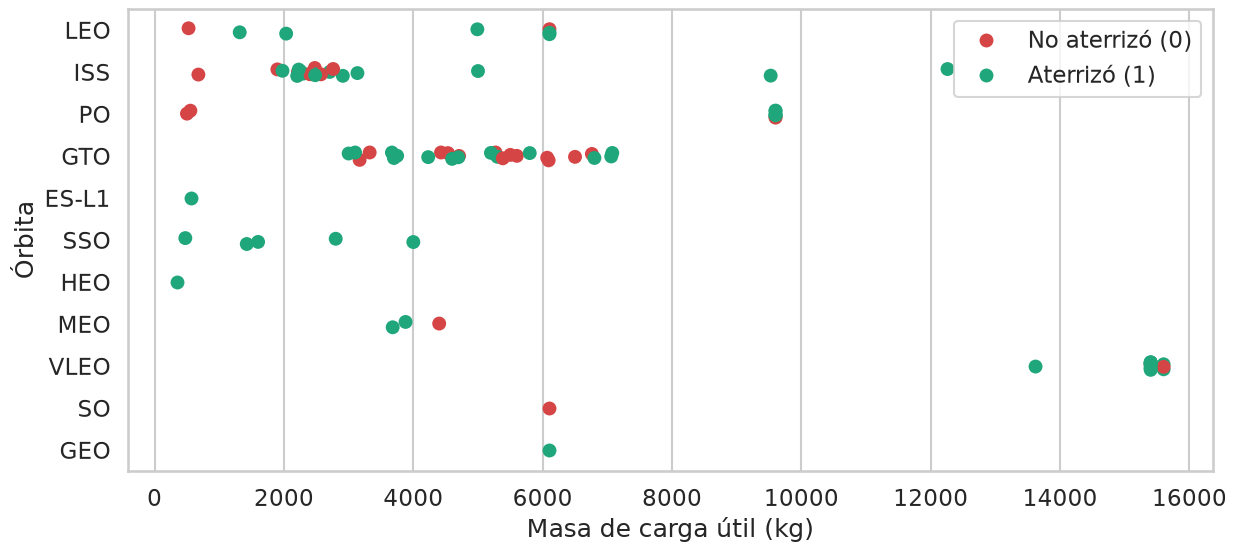

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df, x="PayloadMass", y="Orbit", hue="Class", palette=CLASS_PALETTE,
              size=10, jitter=0.1, ax=ax)
ax.set(xlabel="Masa de carga útil (kg)", ylabel="Órbita")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=[CLASS_LABELS[0], CLASS_LABELS[1]], title=None)
save(fig, "eda_payload_vs_orbit.png")
plt.show()

**Lectura:** con cargas pesadas, los aterrizajes exitosos son más frecuentes en órbitas Polar, LEO e ISS.
En GTO se mezclan éxitos y fallos en todo el rango de masa.

## 7. Tendencia anual de la tasa de éxito

guardada ../images/eda_yearly_trend.png


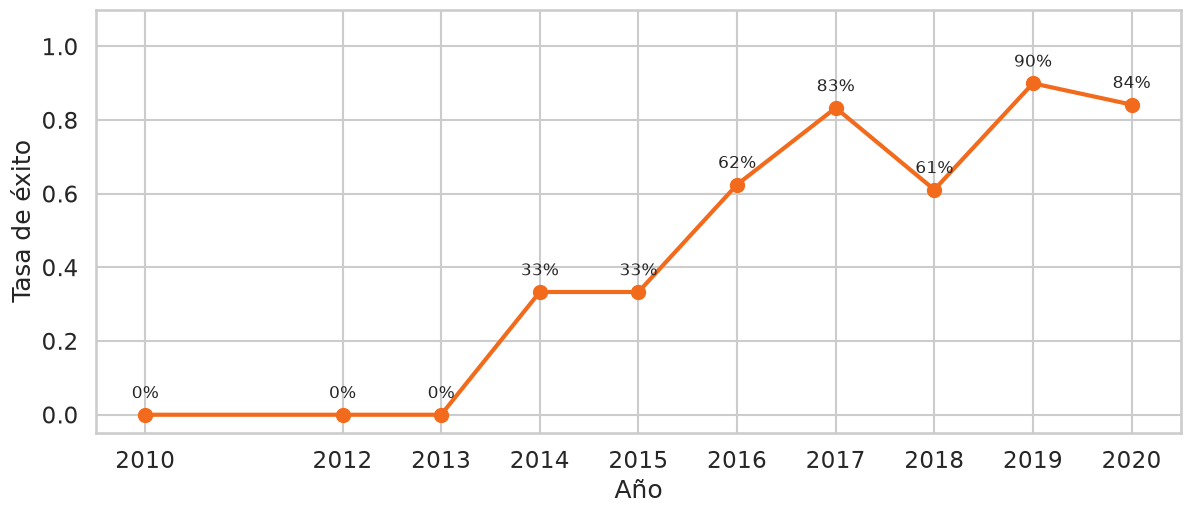

Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.333333
2015    0.333333
2016    0.625000
2017    0.833333
2018    0.611111
2019    0.900000
2020    0.842105
Name: Class, dtype: float64

In [10]:
yearly = df.groupby("Year")["Class"].mean()
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(yearly.index, yearly.values, marker="o", markersize=10, linewidth=3, color="#F26B1D")
for x, y in yearly.items():
    ax.annotate(f"{y:.0%}", (x, y), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=12)
ax.set(xlabel="Año", ylabel="Tasa de éxito", ylim=(-0.05, 1.1), xticks=yearly.index)
save(fig, "eda_yearly_trend.png")
plt.show()
yearly

**Lectura:** la tasa de éxito sube de forma sostenida desde 2013 hasta 2020 (con un leve retroceso en 2018).

## 8. Ingeniería de características (*feature engineering*)

Se seleccionan las variables predictoras y se convierten las categóricas (`Orbit`, `LaunchSite`,
`LandingPad`, `Serial`) en columnas binarias con **One-Hot Encoding** (`pd.get_dummies`).

In [11]:
features = df[["FlightNumber", "PayloadMass", "Orbit", "LaunchSite", "Flights", "GridFins", "Reused",
               "Legs", "LandingPad", "Block", "ReusedCount", "Serial"]]
features_one_hot = pd.get_dummies(features, columns=["Orbit", "LaunchSite", "LandingPad", "Serial"])
features_one_hot = features_one_hot.astype("float64")
print(features_one_hot.shape)
features_one_hot.head()

(90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
features_one_hot.to_csv(DATA_DIR / "dataset_part_3.csv", index=False)

site_stats = df.groupby("LaunchSite")["Class"].agg(["count", "mean"])
summary = {
    "rows": int(len(df)),
    "n_features_one_hot": int(features_one_hot.shape[1]),
    "success_rate_by_orbit": {k: round(float(v), 4) for k, v in orbit_rate.items()},
    "launches_by_orbit": df["Orbit"].value_counts().to_dict(),
    "success_rate_by_year": {str(k): round(float(v), 4) for k, v in yearly.items()},
    "launches_by_site": {k: int(v) for k, v in site_stats["count"].items()},
    "success_rate_by_site": {k: round(float(v), 4) for k, v in site_stats["mean"].items()},
}
(RESULTS_DIR / "eda.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
summary

{'rows': 90,
 'n_features_one_hot': 80,
 'success_rate_by_orbit': {'ES-L1': 1.0,
  'GEO': 1.0,
  'HEO': 1.0,
  'SSO': 1.0,
  'VLEO': 0.8571,
  'LEO': 0.7143,
  'PO': 0.6667,
  'MEO': 0.6667,
  'ISS': 0.619,
  'GTO': 0.5185,
  'SO': 0.0},
 'launches_by_orbit': {'GTO': 27,
  'ISS': 21,
  'VLEO': 14,
  'PO': 9,
  'LEO': 7,
  'SSO': 5,
  'MEO': 3,
  'ES-L1': 1,
  'HEO': 1,
  'SO': 1,
  'GEO': 1},
 'success_rate_by_year': {'2010': 0.0,
  '2012': 0.0,
  '2013': 0.0,
  '2014': 0.3333,
  '2015': 0.3333,
  '2016': 0.625,
  '2017': 0.8333,
  '2018': 0.6111,
  '2019': 0.9,
  '2020': 0.8421},
 'launches_by_site': {'CCAFS SLC 40': 55, 'KSC LC 39A': 22, 'VAFB SLC 4E': 13},
 'success_rate_by_site': {'CCAFS SLC 40': 0.6,
  'KSC LC 39A': 0.7727,
  'VAFB SLC 4E': 0.7692}}

## Conclusiones del EDA

1. **La experiencia cuenta:** cuanto mayor es el número de vuelo, mayor la probabilidad de aterrizar.
2. **La órbita importa:** las órbitas bajas o de pocas misiones tienen mejor tasa; GTO es la más difícil.
3. **La tendencia es claramente positiva** desde 2013.
4. El dataset final para el modelo tiene una fila por lanzamiento y todas las variables en formato numérico.